# La ruta paga el pozo

El costo de la arena que se publica, 97 dólares por tonelada hasta el pozo,
no incluye la ruta. La pagan Vialidad, las provincias y los que viven al
costado. Este notebook mide ese costo con el único dato público que lo
permite: el tránsito medio diario de 2017 por tramo de ruta nacional, el
último publicado tramo por tramo por IDE Transporte, contra las pasadas de
camiones de arena que salen del registro de fractura año a año. Y lo
convierte en desgaste con la ley de la cuarta potencia, la regla con la que
se diseña un pavimento desde 1960.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, json
sys.path.insert(0, "../src")
import geopandas as gpd, pandas as pd, numpy as np
from shapely.geometry import LineString
from IPython.display import IFrame, Image, display

from alab import DATA_RAW, DATA_PROC, DOCS, FIGURES
from alab.demand import read_fracture
from alab.route import sand_route
from alab.animation import SUPUESTOS, yearly_series
from alab.logistics import CHAINS, scenarios
from alab.roads import ESAL, AUTOS_POR_PASADA, route_segments, pressure, exceeded, by_route, passages_by_chain, pressure_figure
from alab.lab import sand_lab_html
pd.set_option("display.width", 180); pd.set_option("display.max_colwidth", 70)

## 1. La ruta, tramo por tramo

La traza real de Ibicuy a Añelo se muestrea cada 2 km y a cada muestra se le
asigna el tramo de ruta nacional con tránsito medido más cercano. Donde no
hay ninguno a menos de 1,5 km, la ruta va por caminos provinciales sin dato:
la RP 45 en Entre Ríos, la RP 20 en La Pampa y la RP 7 en Neuquén. Lo mismo
para el tramo en camión de la cadena por barcaza, la RN 22 de Bahía Blanca a
Añelo.

In [2]:
route = sand_route(cache=DATA_RAW / "ruta_arena_osrm.json"); km = float(route.iloc[0]["km"])
bb = json.loads((DATA_RAW / "ruta_bahiablanca_anelo_osrm.json").read_text(encoding="utf-8"))
route_bb = gpd.GeoDataFrame({"km": [round(bb["routes"][0]["distance"] / 1000)]}, geometry=[LineString(bb["routes"][0]["geometry"]["coordinates"])], crs="EPSG:4326")
tmda = gpd.read_file(DATA_RAW / "tmda_rutas_nacionales.geojson")
seg = gpd.GeoDataFrame(pd.concat([route_segments(tmda, route, "Ibicuy"), route_segments(tmda, route_bb, "Bahía Blanca")], ignore_index=True), crs="EPSG:4326")
ib = seg[seg.corredor == "Ibicuy"]
print(f"ruta de {km:,.0f} km; {len(ib)} tramos con tránsito medido que cubren {ib.km.sum():,.0f} km; el resto son rutas provinciales sin dato")
ib.drop(columns="geometry")

ruta de 1,461 km; 27 tramos con tránsito medido que cubren 1,154 km; el resto son rutas provinciales sin dato


,cod_ruta,ruta,corredor,km,km_desde,tmda17
0,0012,RN 12,Ibicuy,22.0,38,19700
1,0012,RN 12,Ibicuy,78.0,84,19700
2,0005,RN 5,Ibicuy,26.0,230,15560
3,0005,RN 5,Ibicuy,30.0,256,8685
4,0005,RN 5,Ibicuy,28.0,286,8030
5,0005,RN 5,Ibicuy,20.0,314,7230
6,0005,RN 5,Ibicuy,34.0,334,6750
7,0005,RN 5,Ibicuy,60.0,368,5035
8,0005,RN 5,Ibicuy,44.0,428,4900
9,0005,RN 5,Ibicuy,56.0,472,4350


## 2. Las pasadas de arena contra el tránsito de 2017

Cada tonelada de arena nacional del registro de fractura se convierte en
viajes de 30 toneladas, 300 días por año, y cada viaje son dos pasadas por
el tramo: una cargado y otra vacío de vuelta. Se comparan con todo el
tránsito que el tramo tenía en 2017, autos incluidos, antes del salto de
Vaca Muerta.

In [3]:
frac = read_fracture(DATA_RAW / "fractura_adjunto_iv.csv")
y = yearly_series(frac, route_km=km); y = y[y.anio <= 2026]
pr = pressure(seg, y)
ex = exceeded(pr[pr.corredor == "Ibicuy"])
ex

,anio,pasadas_dia,tramos,tramos_superados,km_superados,peor_ruta,peor_pct
0,2012,1,27,0,0,RN 152,0.5
1,2013,5,27,0,0,RN 152,2.4
2,2014,15,27,0,0,RN 152,7.7
3,2015,16,27,0,0,RN 152,8.2
4,2016,67,27,0,0,RN 152,33.8
5,2017,130,27,0,0,RN 152,66.1
6,2018,208,27,1,54,RN 152,105.4
7,2019,278,27,1,54,RN 152,141.3
8,2020,157,27,0,0,RN 152,79.5
9,2021,498,27,3,198,RN 152,252.6


In [4]:
by_route(pr[pr.corredor == "Ibicuy"], 2025)

,ruta,km,tmda17_min,tmda17_max,pasadas_dia,pct_min,pct_max
0,RN 12,100.0,19700,19700,1122,5.7,5.7
1,RN 5,540.0,3350,15560,1122,7.2,33.5
2,RN 35,74.0,3266,5200,1122,21.6,34.4
3,RN 152,286.0,197,1960,1122,57.3,569.8
4,RN 151,154.0,4900,7950,1122,14.1,22.9


En 2025 son 1.122 pasadas por día. En la RN 152, entre General Acha y Casa
de Piedra, hay dos tramos que en 2017 tenían 197 y 290 vehículos por día en
total: las pasadas de arena de hoy son cuatro a seis veces todo lo que
pasaba entonces. Desde 2021, 198 km de esa ruta tienen más camiones de arena
que tránsito total tenían en 2017. En la RN 5 y la RN 35, entre Luján y Santa
Rosa, la arena es entre el 7 y el 36 % del tránsito de 2017; en la RN 151,
entre el 14 y el 23 %.

Sin usar la prensa, el modelo da 1.122 pasadas diarias. La Pampa cuenta
"1.200 camiones diarios" para fundamentar una tasa vial (Diario Río Negro,
30/7/2026), y en Puelches dicen que la RN 152 pasó de 200 o 300 camiones a
"entre 800 y 1.200" (La Arena, 9/5/2026). Coinciden.

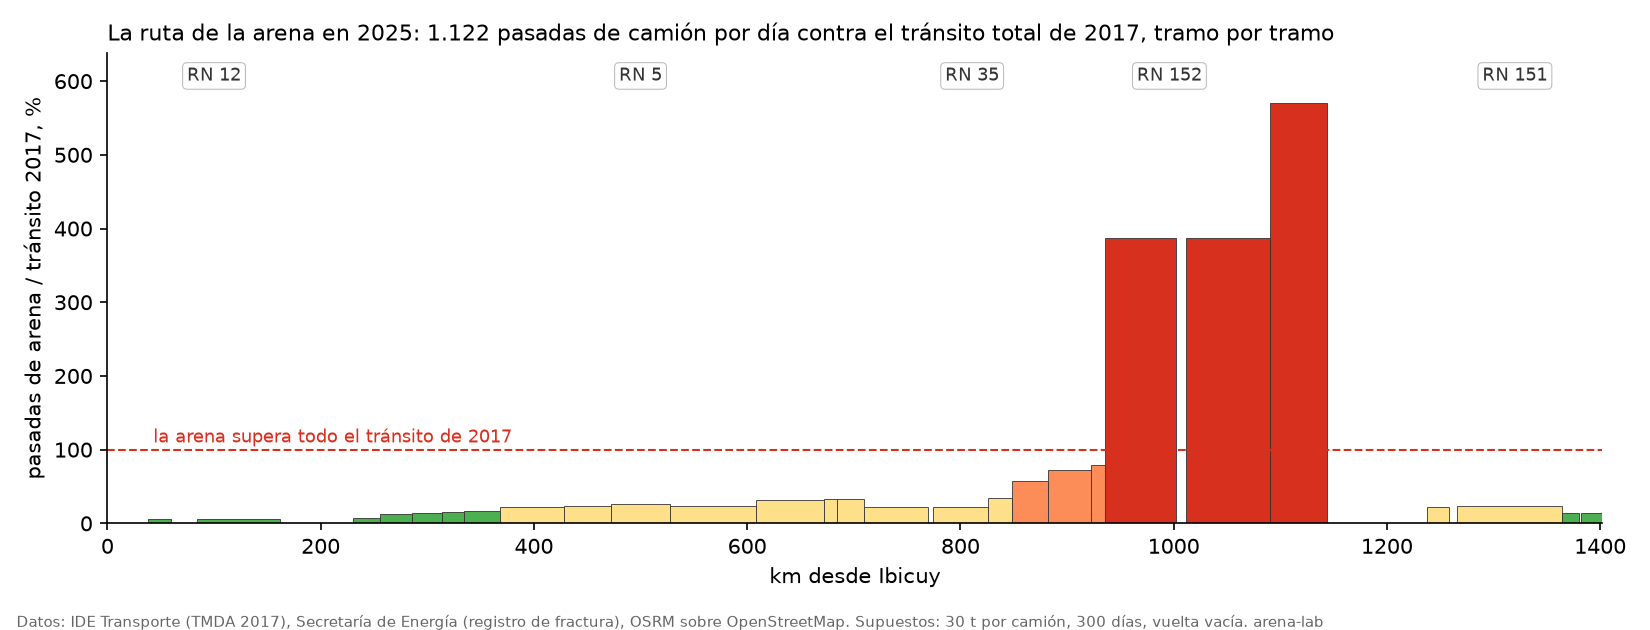

In [5]:
pressure_figure(pr, 2025, FIGURES / "presion_ruta.png")
Image(FIGURES / "presion_ruta.png")

## 3. El desgaste: la ley de la cuarta potencia

El AASHO Road Test de 1958 a 1960 midió que el daño al pavimento crece con la
cuarta potencia de la carga por eje. Con las tablas de la Guía AASHTO 1993, un
semirremolque de cinco ejes y 36 toneladas genera 4,26 ejes equivalentes por
pasada; un auto, 0,0004. Cada camión que pasa desgasta como unos 10.000 autos.

In [6]:
print("ESAL por pasada:", ESAL, "-> autos por pasada de camión:", f"{AUTOS_POR_PASADA:,}")
p25 = pr[(pr.corredor == "Ibicuy") & (pr.anio == 2025)].iloc[0]
print(f"2025: {p25.pasadas_dia:,} pasadas por día equivalen, en desgaste, a {p25.autos_equiv_dia/1e6:,.1f} millones de autos por día en cada tramo de la ruta")

ESAL por pasada: {'semi_5_ejes': 4.26, 'auto': 0.0004} -> autos por pasada de camión: 10,650
2025: 1,122 pasadas por día equivalen, en desgaste, a 12.0 millones de autos por día en cada tramo de la ruta


En la RN 152, donde en 2017 pasaban 197 vehículos por día, hoy pasan 1.122
camiones de arena que desgastan como 12 millones de autos. No hace falta
modelo para saber quién rompe el pavimento; el modelo sirve para decir
cuánto, y para pasar de "la ruta está rota" a "la ruta la rompe la arena, y
esto es lo que costaría sacarla de ahí".

## 4. Cada cadena, en pasadas por día

Las cadenas de `logistics.py` se miden ahora también en camiones que dejan
de pasar por Puelches. El tren y la hidrovía sacan de la ruta larga a todos;
la cadena por barcaza y camión los saca de la RN 5 y la RN 152 y los pone en
la RN 22, que cerca de Neuquén ya tenía tránsito alto en 2017.

In [7]:
passages_by_chain(float(y.loc[y.anio == 2025, "nat_t"].iloc[0]))

,cadena,km_camion_largo,pasadas_dia,autos_equiv_dia
0,"camión directo, hoy",1461,1122,11954572
1,barcaza a Bahía Blanca y camión,620,1122,11954572
2,"barcaza, Tren Norpatagónico y camión",0,0,0
3,hidrovía patagónica por el río Negro,0,0,0
4,arena cercana de Neuquén,0,0,0
5,"arenoducto, hipotético",0,0,0


In [8]:
scenarios()[["demanda_mt", "cadena", "costo_musd", "camiones_larga_distancia", "pasadas_dia_rutas_nacionales", "co2_kt"]]

,demanda_mt,cadena,costo_musd,camiones_larga_distancia,pasadas_dia_rutas_nacionales,co2_kt
0,5.0,"camión directo, hoy",485.0,3333,1111,1000.8
1,5.0,barcaza a Bahía Blanca y camión,313.5,1415,1111,500.4
2,5.0,"barcaza, Tren Norpatagónico y camión",176.0,0,0,189.8
3,5.0,hidrovía patagónica por el río Negro,240.0,0,0,240.1
4,5.0,arena cercana de Neuquén,149.4,0,0,41.1
5,5.0,"arenoducto, hipotético",345.0,0,0,166.2
6,8.0,"camión directo, hoy",776.0,5333,1778,1601.3
7,8.0,barcaza a Bahía Blanca y camión,501.6,2263,1778,800.7
8,8.0,"barcaza, Tren Norpatagónico y camión",281.6,0,0,303.6
9,8.0,hidrovía patagónica por el río Negro,384.0,0,0,384.2


A 8 millones de toneladas, la cifra que se proyecta para 2027, el camión
directo son 1.778 pasadas por día: nueve veces el tránsito total de 2017 en
el peor tramo de la RN 152.

## 5. Lo que hay del otro lado: obras y peajes anunciados

Para leer estos números al lado de lo que se está haciendo, verificado en
septiembre de 2026:

- Entre Ríos: bacheo con cemento en la RP 45 de Ibicuy y un plan de 469 km en
  24 meses; concesión privada prevista con peaje a pesados, 40 a 50 millones
  de dólares (Más Energía, 7/9/2026).
- La Pampa: proyecto de tasa vial a los camiones de cinco o más ejes,
  exentos los pampeanos; en la RP 13 el tránsito de camiones pasó de 17 por
  día en 2015 a 226 en 2026 (Diario Río Negro, 30/7/2026).
- Río Negro: concesión de 305 km de RN 22 y RN 151 con 60 millones de dólares
  de Fonplata, a 20 años; la RN 151 declarada en estado crítico (Más Energía,
  7/9/2026).
- Nación: la RN 5 concesionada en agosto de 2026 a 20 años, sin obras de
  ampliación en el contrato; calzada de 1961 de 3,30 a 3,65 m por mano para
  camiones de 2,60 m (La Nación, reproducido por Diario Neuquino, 11/9/2026).
- Neuquén: bypass de Añelo de 25 km, primer tramo habilitado en mayo de 2026.

Contra 354 millones de dólares por año de flete en 2025, las obras anunciadas
para toda la ruta suman del orden de 100 millones, una sola vez.

## 6. El laboratorio y la ruta animada

El laboratorio deja mover la demanda, la carga por camión y el reparto por
cadena, y devuelve costo, camiones, pasadas por tramo, desgaste, emisiones y
repago del tren. La ruta animada ahora pinta cada tramo según cuánto pesa la
arena en su tránsito de 2017, año a año.

In [9]:
seg.to_parquet(DATA_PROC / "tramos_ruta.parquet"); pr.to_csv(DATA_PROC / "presion_ruta.csv", index=False); ex.to_csv(DATA_PROC / "presion_ruta_por_anio.csv", index=False)
lab = sand_lab_html(seg, y, DOCS / "laboratorio_arena.html")
IFrame("../docs/laboratorio_arena.html", width="100%", height=760)

## Límites

- El tránsito de 2017 es el último publicado por tramo. Incluye todos los
  vehículos, y ya tenía camiones de arena: la comparación es contra el total
  de entonces, no contra el tránsito "sin arena".
- Toda la arena nacional se supone por la ruta de Entre Ríos. Hasta 2020 una
  parte venía de Río Negro; desde 2024 la parte de Entre Ríos es el 75 %. Las
  pasadas reales por Puelches son algo menores que las del modelo, y aun así
  la prensa cuenta más camiones de los que el modelo pone.
- Los tramos de IDE Transporte traen calzadas dobles y, en la RN 22 y la RN
  3, varios tramos superpuestos sobre la misma línea. Se toma el de más
  tránsito, así que la presión sobre la RN 22 es un piso.
- La equivalencia de 10.000 autos es la de un semirremolque de 36 toneladas
  brutas; los de la ruta de la arena pesan 53 a 55, y los bitrenes 75. El
  desgaste real por pasada es mayor.
- Las rutas provinciales por donde también pasa la arena, RP 45, RP 20 y RP 7,
  no tienen tránsito publicado y no están.